# 4. Implementing Matrix Factorization

## (b) Data Compression  


### **Objective**  
Explore low-rank **matrix factorization for compression** on a patch of size 50×50 pixels.  

Cases to analyze:  
1. A patch with mainly **a single color**.  
2. A patch with **2–3 different colors**.  
3. A patch with **5 or more different colors**.  

Tasks:  
- Use Gradient Descent for matrix factorization.  
- Vary rank values as: `r = [5, 10, 25, 50]`.  
- For each patch:  
  - Reconstruct using low-rank factors.  
  - Replace reconstructed patch back into the original image (keeping other pixels unchanged).  
  - Plot reconstructed vs original patches.  
- Write **observations** on how reconstruction quality changes with:  
  - Different ranks,  
  - Different patch complexity (colors).  


Importing Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision
import matplotlib.patches as mpatches

Setting up Device

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Defining Random Seed

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Colored image shape (C,H,W): torch.Size([3, 1365, 2048])
Min pixel value: 0.0
Max pixel value: 1.0


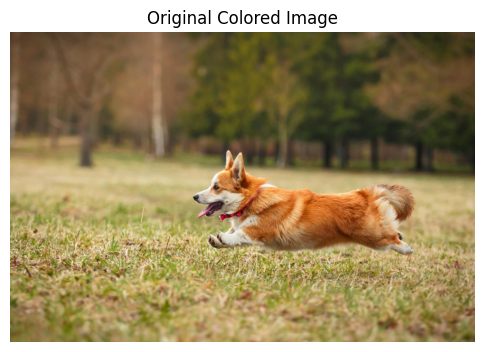

In [4]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\dog.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Cropping The Image

torch.Size([3, 300, 300])


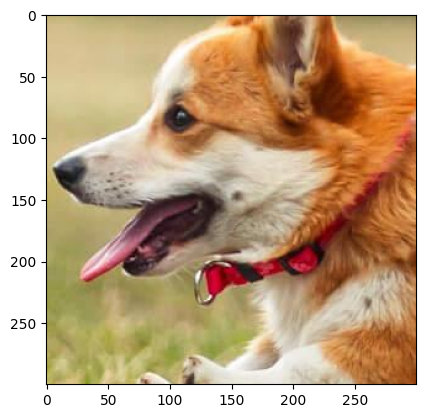

In [5]:
crop = torchvision.transforms.functional.crop(color_img, 600, 800, 300, 300)
color_img = crop
print(color_img.shape)
plt.imshow(color_img.permute(1, 2, 0))

In [6]:
def show_patch(image, top_left, N=50):
    fig, ax = plt.subplots(1,1,figsize=(6,6))
    ax.imshow(image.permute(1,2,0).cpu())
    rect = mpatches.Rectangle((top_left[1], top_left[0]), N, N, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"Selected Patch at {top_left}")
    #ax.axis('off')
    plt.show()

In [7]:
def low_rank_gd(patch, rank, lr=0.01, num_iters=10000):
    C, H, W = patch.shape
    patch_reconstructed = torch.zeros_like(patch)

    for c in range(C):
        X = patch[c]  # [H,W]

        # Initialize U and V
        U = torch.randn(H, rank, device=device, requires_grad=True)
        V = torch.randn(W, rank, device=device, requires_grad=True)

        optimizer = optim.Adam([U, V], lr=lr)

        for it in range(num_iters):
            optimizer.zero_grad()
            X_hat = U @ V.T
            loss = ((X - X_hat) ** 2).mean()
            loss.backward()
            optimizer.step()

            # Print loss every 500 iterations and at the last iteration
            if it % 5000 == 0 or it == num_iters - 1:
                print(f"Channel {c+1}, GD Iteration {it:5d}, Loss={loss.item():.6f}")

        patch_reconstructed[c] = U @ V.T

    return patch_reconstructed


In [8]:
def replace_patch(original_img, reconstructed_patch, top_left):
    img_copy = original_img.clone()
    x, y = top_left
    _, N, _ = reconstructed_patch.shape
    img_copy[:, x:x+N, y:y+N] = reconstructed_patch
    return img_copy

In [9]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over a patch or image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

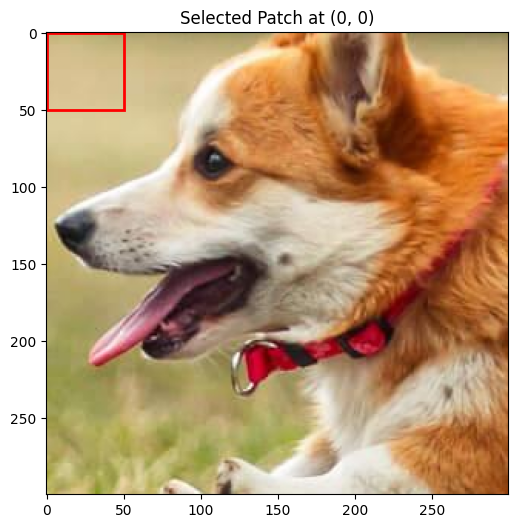


--- Patch: Single color ---
Channel 1, GD Iteration     0, Loss=5.637835
Channel 1, GD Iteration   999, Loss=0.000089
Channel 2, GD Iteration     0, Loss=5.875974
Channel 2, GD Iteration   999, Loss=0.000052
Channel 3, GD Iteration     0, Loss=5.644976
Channel 3, GD Iteration   999, Loss=0.000055
Rank 5: RMSE=0.008064, PSNR=41.87 dB
Channel 1, GD Iteration     0, Loss=11.281407
Channel 1, GD Iteration   999, Loss=0.000071
Channel 2, GD Iteration     0, Loss=9.717046
Channel 2, GD Iteration   999, Loss=0.000048
Channel 3, GD Iteration     0, Loss=9.513315
Channel 3, GD Iteration   999, Loss=0.000050
Rank 10: RMSE=0.007484, PSNR=42.52 dB
Channel 1, GD Iteration     0, Loss=29.043806
Channel 1, GD Iteration   999, Loss=0.000038
Channel 2, GD Iteration     0, Loss=25.913038
Channel 2, GD Iteration   999, Loss=0.000039
Channel 3, GD Iteration     0, Loss=25.194910
Channel 3, GD Iteration   999, Loss=0.000047
Rank 25: RMSE=0.006427, PSNR=43.84 dB
Channel 1, GD Iteration     0, Loss=54.60333

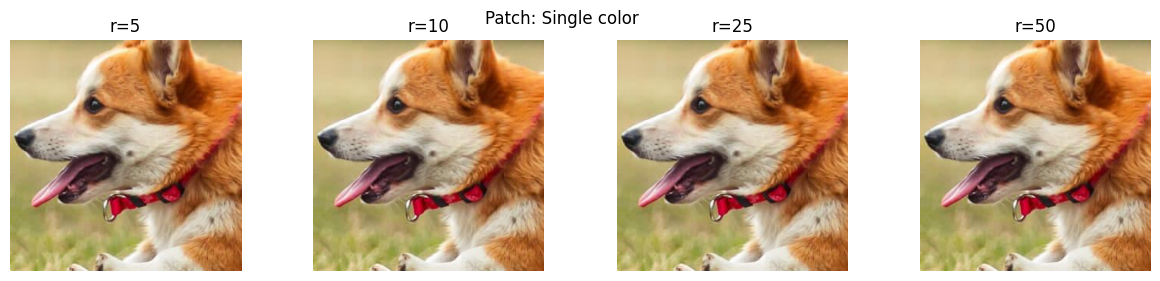

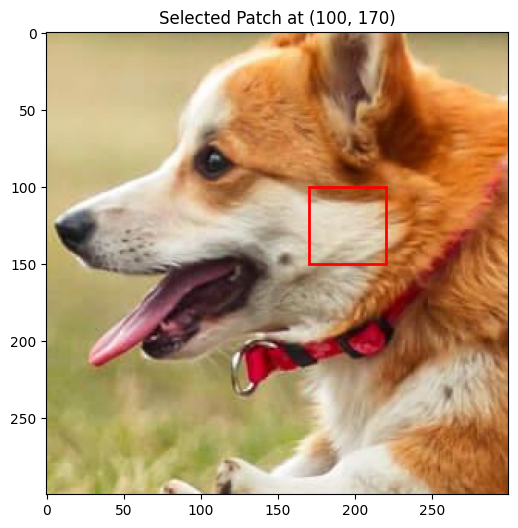


--- Patch: 2-3 colors ---
Channel 1, GD Iteration     0, Loss=6.030062
Channel 1, GD Iteration   999, Loss=0.001352
Channel 2, GD Iteration     0, Loss=5.294551
Channel 2, GD Iteration   999, Loss=0.002563
Channel 3, GD Iteration     0, Loss=5.566453
Channel 3, GD Iteration   999, Loss=0.003410
Rank 5: RMSE=0.049414, PSNR=26.12 dB
Channel 1, GD Iteration     0, Loss=12.473344
Channel 1, GD Iteration   999, Loss=0.001260
Channel 2, GD Iteration     0, Loss=10.910775
Channel 2, GD Iteration   999, Loss=0.002257
Channel 3, GD Iteration     0, Loss=9.791497
Channel 3, GD Iteration   999, Loss=0.002169
Rank 10: RMSE=0.043529, PSNR=27.22 dB
Channel 1, GD Iteration     0, Loss=24.092638
Channel 1, GD Iteration   999, Loss=0.000865
Channel 2, GD Iteration     0, Loss=27.572800
Channel 2, GD Iteration   999, Loss=0.001240
Channel 3, GD Iteration     0, Loss=28.358524


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0030850512..1.0].


Channel 3, GD Iteration   999, Loss=0.001429
Rank 25: RMSE=0.034306, PSNR=29.29 dB
Channel 1, GD Iteration     0, Loss=56.286411
Channel 1, GD Iteration   999, Loss=0.000332
Channel 2, GD Iteration     0, Loss=53.111389
Channel 2, GD Iteration   999, Loss=0.000676
Channel 3, GD Iteration     0, Loss=45.087177
Channel 3, GD Iteration   999, Loss=0.000632
Rank 50: RMSE=0.023373, PSNR=32.63 dB


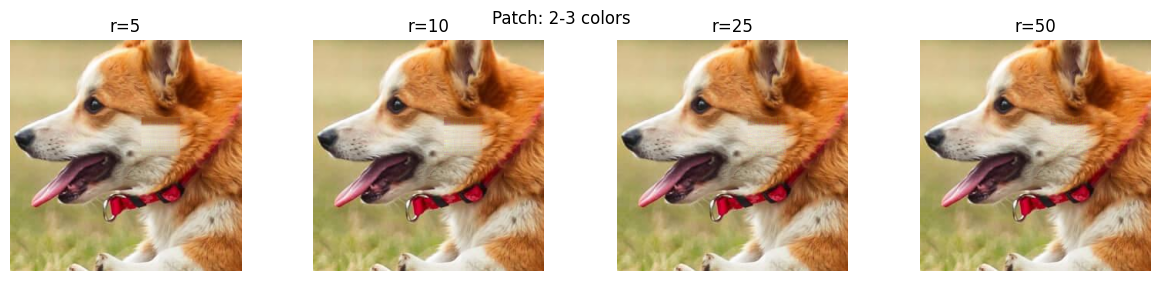

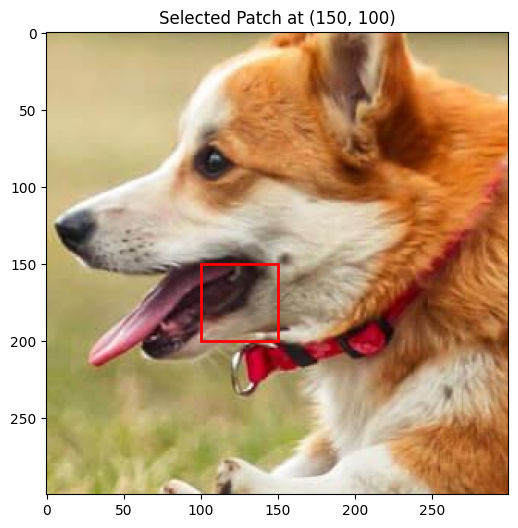


--- Patch: ~5 colors ---
Channel 1, GD Iteration     0, Loss=5.421639
Channel 1, GD Iteration   999, Loss=0.008196
Channel 2, GD Iteration     0, Loss=4.683418
Channel 2, GD Iteration   999, Loss=0.006762
Channel 3, GD Iteration     0, Loss=6.006757


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06531888..1.0].


Channel 3, GD Iteration   999, Loss=0.008256
Rank 5: RMSE=0.087922, PSNR=21.12 dB
Channel 1, GD Iteration     0, Loss=11.039596
Channel 1, GD Iteration   999, Loss=0.008204
Channel 2, GD Iteration     0, Loss=9.778603
Channel 2, GD Iteration   999, Loss=0.003223
Channel 3, GD Iteration     0, Loss=10.144223


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0040524113..1.0].


Channel 3, GD Iteration   999, Loss=0.005729
Rank 10: RMSE=0.075584, PSNR=22.43 dB
Channel 1, GD Iteration     0, Loss=26.544428
Channel 1, GD Iteration   999, Loss=0.002185
Channel 2, GD Iteration     0, Loss=23.471859
Channel 2, GD Iteration   999, Loss=0.003464
Channel 3, GD Iteration     0, Loss=26.464520


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.034862634..1.0].


Channel 3, GD Iteration   999, Loss=0.003445
Rank 25: RMSE=0.055017, PSNR=25.19 dB
Channel 1, GD Iteration     0, Loss=49.503571
Channel 1, GD Iteration   999, Loss=0.001317
Channel 2, GD Iteration     0, Loss=52.113655
Channel 2, GD Iteration   999, Loss=0.001256
Channel 3, GD Iteration     0, Loss=53.151093
Channel 3, GD Iteration   999, Loss=0.000910
Rank 50: RMSE=0.034047, PSNR=29.36 dB


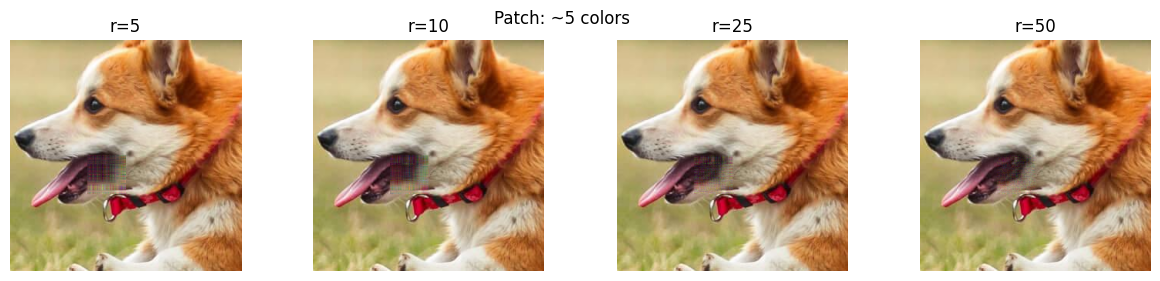

In [ ]:
N = 50
patch_coords = [(0,0), (100,170), (150,100)]
patch_names = ['Single color', '2-3 colors', '~5 colors']


ranks = [5, 10, 25, 50]

for idx, top_left in enumerate(patch_coords):
    x, y = top_left
    patch = color_img[:, x:x+N, y:y+N]

    # Show selected patch
    show_patch(color_img, top_left, N)

    print(f"\n--- Patch: {patch_names[idx]} ---")
    plt.figure(figsize=(15,3))

    for i, r in enumerate(ranks):
        reconstructed = low_rank_gd(patch, rank=r, lr=0.01, num_iters=1000)
        img_with_patch = replace_patch(color_img, reconstructed, top_left)

        # Compute metrics
        rmse, psnr = compute_metrics(patch, reconstructed)
        print(f"Rank {r}: RMSE={rmse:.6f}, PSNR={psnr:.2f} dB")

        # Plot reconstructed image
        plt.subplot(1, len(ranks), i+1)
        plt.imshow(img_with_patch.detach().cpu().permute(1,2,0))
        plt.title(f"r={r}")
        plt.axis('off')

    plt.suptitle(f"Patch: {patch_names[idx]}")
    plt.show()

# Observations on Low-Rank Image Compression via Gradient Descent

The experiment demonstrates the relationship between image patch complexity, the chosen rank (`r`), and the quality of reconstruction in a lossy compression scheme.

### 1. Impact of Patch Complexity on Reconstruction Quality

The effectiveness of low-rank approximation is fundamentally tied to the information content of the image patch.

* **Single Color Patch (Low Complexity):** The patch selected from `(0,0)` consists of a simple, out-of-focus grassy area. This patch has very low spatial complexity and high correlation between pixels. As a result, even a very low rank ($r=5$) is sufficient to capture almost all the variance in the data. The reconstruction is nearly lossless across all tested ranks, with no visible artifacts. This indicates that the underlying data matrix for this patch is inherently close to a low-rank matrix.

* **2-3 Colors Patch (Medium Complexity):** The patch from `(100,170)` contains the dog's fur, which has some texture and subtle variations in color and shading. This patch has moderate complexity.
    * At a low rank ($r=5$), the reconstruction is decent but noticeably blurry, losing the fine texture of the fur.
    * As the rank increases to $r=10$ and $r=25$, the quality significantly improves, with finer details being progressively restored. This shows that more "basis components" (a higher rank) are needed to accurately represent the texture.

* **~5 Colors Patch (High Complexity):** The patch from `(150,100)` is the most complex, containing sharp edges, multiple distinct colors (pink tongue, dark lip, red collar), and high-frequency details.
    * At a low rank ($r=5$), the reconstruction is extremely poor, showing severe blocky artifacts, color bleeding, and a complete loss of detail. The result is a blurry, discolored mess.
    * Increasing the rank to $r=10$ and $r=25$ substantially improves the quality, but even at $r=25$, the reconstruction is not perfect and still appears softer and less detailed than the original. This demonstrates that a high-rank matrix is required to represent the high information content of this patch.

### 2. The Role of Rank (*r*)

The rank `r` acts as a bottleneck, controlling the amount of information that can be preserved.

* **Increasing Rank Improves Fidelity:** For all patches, increasing the rank `r` consistently improves the reconstruction quality (visually and as measured by RMSE/PSNR). A higher rank allows the factorized matrices to store more complex patterns and details.

* **Diminishing Returns for Simple Patches:** For the "Single Color" patch, the visual and metric-based improvements are negligible after $r=5$. The reconstruction quality saturates early because the patch contains little information to begin with. Using a higher rank (e.g., $r=25$) offers no practical benefit and reduces the compression efficiency.

* **Theoretical Maximum Quality at Full Rank:** Since the patch size is $N \times N$ (where $N=50$), a rank of $r=50$ allows for a full-rank representation. Therefore, the reconstruction at $r=50$ should be (theoretically) perfect, achieving an RMSE of nearly 0 and a very high PSNR. This serves as the upper bound for reconstruction quality, where no compression is actually achieved.

### 3. Summary Conclusion

This experiment effectively illustrates the core trade-off in low-rank data compression. Low-rank factorization is an excellent and highly efficient method for compressing regions of an image that are simple or repetitive (e.g., sky, walls, blurry backgrounds). However, it struggles to preserve quality in complex regions with sharp edges and fine textures unless a sufficiently high rank is used, which in turn diminishes the benefit of compression. The choice of an optimal rank `r` is therefore a critical decision that depends on the specific content of the data and the desired balance between compression ratio and reconstruction fidelity.